In [9]:
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("leo085/MoCA-Long-iWatch-FT/cdvp4abb")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_random_hip = pd.DataFrame(rows)

print(chap_random_hip.shape)   # should now be full length, not capped at 500
# chap_random_hip = chap_random_hip[["_step", "perf/bal_acc", "perf/test_loss"]]

(12921, 16)


In [10]:
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("/leo085/MoCA-Long-iWatch-FT/runs/p5or8b5t")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_ft_hip = pd.DataFrame(rows)

print(chap_ft_hip.shape)   # should now be full length, not capped at 500
# chap_ft_hip = chap_ft_hip[["_step", "perf/bal_acc", "perf/test_loss"]]

(12921, 16)


In [11]:
import matplotlib.pyplot as plt
import os

def plot_chap_nature(df_ft, df_random,
                     label_ft="CHAP Fine-Tuned",
                     label_random="CHAP Random Init",
                     save_path='figures'):
    """
    Nature-style plot for CHAP models with epoch inferred from row index.
    Assumes 40 valid epochs in both fine-tuned and randomly initialized runs.
    """

    # Filter and index
    df_ft = df_ft[["perf/bal_acc", "perf/test_loss"]].dropna().reset_index(drop=True)
    df_random = df_random[["perf/bal_acc", "perf/test_loss"]].dropna().reset_index(drop=True)

    df_ft["epoch"] = range(len(df_ft))
    df_random["epoch"] = range(len(df_random))

    assert len(df_ft) == len(df_random) == 40, "Expected 40 epochs per run"

    # Nature-style font and line settings
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
        "font.size": 9,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.5,
        "lines.linewidth": 1.0,
        "legend.frameon": False,
        "savefig.dpi": 600
    })

    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))  # ~178mm × 81mm

    color_ft = "#0072B2"
    color_random = "#D55E00"

    # Plot panel a: Balanced Accuracy
    axes[0].plot(df_random["epoch"], df_random["perf/bal_acc"],
                 label=label_random, color=color_random)
    axes[0].plot(df_ft["epoch"], df_ft["perf/bal_acc"],
                 label=label_ft, color=color_ft)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Validation Balanced Accuracy")
    axes[0].text(-0.12, 1.05, "a", transform=axes[0].transAxes,
                 fontsize=10, fontweight='bold', va='top', ha='right')

    # Plot panel b: Test Loss
    axes[1].plot(df_random["epoch"], df_random["perf/test_loss"],
                 label=label_random, color=color_random)
    axes[1].plot(df_ft["epoch"], df_ft["perf/test_loss"],
                 label=label_ft, color=color_ft)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation Loss")
    axes[1].text(-0.12, 1.05, "b", transform=axes[1].transAxes,
                 fontsize=10, fontweight='bold', va='top', ha='right')

    # Clean axes
    for ax in axes:
        ax.tick_params(direction="out", length=3, width=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)

    # Place legend inside panel b, top left
    axes[1].legend(loc="upper right", frameon=False, handlelength=1.5)

    plt.tight_layout(w_pad=2)

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, format="pdf", bbox_inches="tight", transparent=True)
    else:
        plt.show()


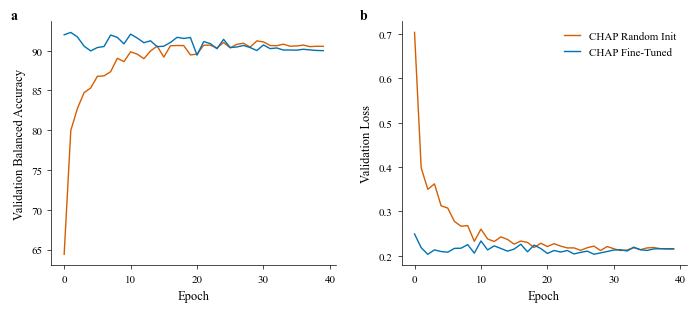

In [12]:
plot_chap_nature(chap_ft_hip, chap_random_hip,save_path='figures/chap_hip_plot.pdf')

In [13]:
# 
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("/leo085/MoCA-Long-iWatch-FT/runs/7zd1josa")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_random_wrist = pd.DataFrame(rows)


chap_random_wrist = pd.DataFrame(rows)

print(chap_random_wrist.shape)   # should now be full length, not capped at 500
# chap_random_wrist = chap_random_wrist[["_step", "perf/bal_acc", "perf/test_loss"]]

(13321, 16)


In [14]:

# 
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("/leo085/MoCA-Long-iWatch-FT/runs/kmcfojlc")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_ft_wrist = pd.DataFrame(rows)


chap_ft_wrist = pd.DataFrame(rows)

print(chap_ft_wrist.shape)   # should now be full length, not capped at 500
# chap_ft_wrist = chap_ft_wrist[["_step", "perf/bal_acc", "perf/test_loss"]]

(13321, 16)


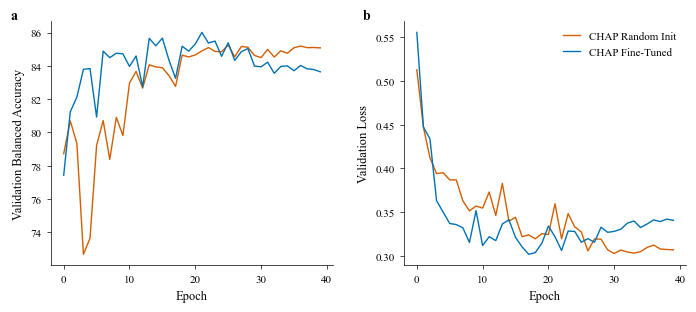

In [15]:
plot_chap_nature(chap_ft_wrist, chap_random_wrist,save_path='figures/chap_wrist_plot.pdf')

# Limited Label

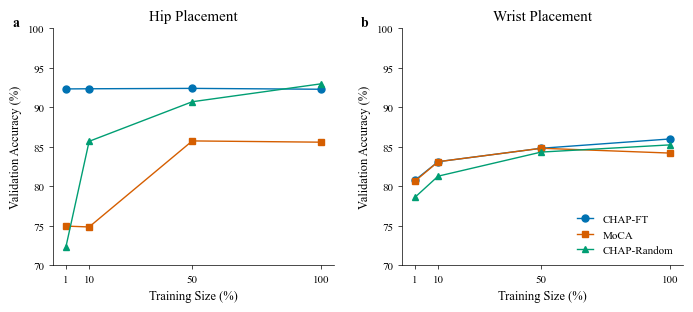

In [8]:
import matplotlib.pyplot as plt
import os

# Nature-style font and line settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "legend.frameon": False,
    "savefig.dpi": 600
})

# Training sizes
train_sizes = [1, 10, 50, 100]

# Validation accuracy for each model and placement
chap_ft_hip = [92.33, 92.35, 92.40, 92.29]
moca_hip = [74.97, 74.86, 85.75, 85.59]
chap_random_hip = [72.34, 85.70, 90.71, 92.98]

chap_ft_wrist = [80.77, 83.12, 84.82, 86.00]
moca_wrist = [80.65, 83.12, 84.82, 84.21]
chap_random_wrist = [78.61, 81.29, 84.34, 85.25]

# Define colors
color_chap = "#0072B2"
color_moca = "#D55E00"
color_random = "#009E73"

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))  # ~178mm × 81mm

# HIP Plot
axes[0].plot(train_sizes, chap_ft_hip, marker='o', label="CHAP-FT", color=color_chap, markersize=5)
axes[0].plot(train_sizes, moca_hip, marker='s', label="MoCA", color=color_moca, markersize=5)
axes[0].plot(train_sizes, chap_random_hip, marker='^', label="CHAP-Random", color=color_random, markersize=5)

axes[0].set_xlabel("Training Size (%)")
axes[0].set_ylabel("Validation Accuracy (%)")
axes[0].set_title("Hip Placement")
axes[0].set_ylim(70, 100)
axes[0].set_xticks(train_sizes)  # Only show ticks at training sizes
axes[0].tick_params(direction="out", length=3, width=0.5)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(False)
axes[0].text(-0.12, 1.05, "a", transform=axes[0].transAxes,
             fontsize=10, fontweight='bold', va='top', ha='right')

# WRIST Plot
axes[1].plot(train_sizes, chap_ft_wrist, marker='o', label="CHAP-FT", color=color_chap, markersize=5)
axes[1].plot(train_sizes, moca_wrist, marker='s', label="MoCA", color=color_moca, markersize=5)
axes[1].plot(train_sizes, chap_random_wrist, marker='^', label="CHAP-Random", color=color_random, markersize=5)

axes[1].set_xlabel("Training Size (%)")
axes[1].set_ylabel("Validation Accuracy (%)")
axes[1].set_title("Wrist Placement")
axes[1].set_ylim(70, 100)
axes[1].set_xticks(train_sizes)  # Only show ticks at training sizes
axes[1].tick_params(direction="out", length=3, width=0.5)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(False)
axes[1].text(-0.12, 1.05, "b", transform=axes[1].transAxes,
             fontsize=10, fontweight='bold', va='top', ha='right')

# Legend inside second panel
axes[1].legend(loc="lower right", frameon=False, handlelength=1.5)

# Final layout and save
plt.tight_layout(w_pad=2)
save_path = "figures/chap_moca_accuracy_curve.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, format="pdf", bbox_inches="tight", transparent=True)
plt.show()
